<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/Autoencoders_MNIST_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Reshape
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split

import tensorflow as tf

print("Tensorflow version:",tf.__version__)

Tensorflow version: 2.20.0


In [2]:
(X_train, y_train), (X_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print('Training Data Shape:',X_train.shape)
print('Testing Data Sghape:',X_test.shape)

Training Data Shape: (60000, 28, 28)
Testing Data Sghape: (10000, 28, 28)


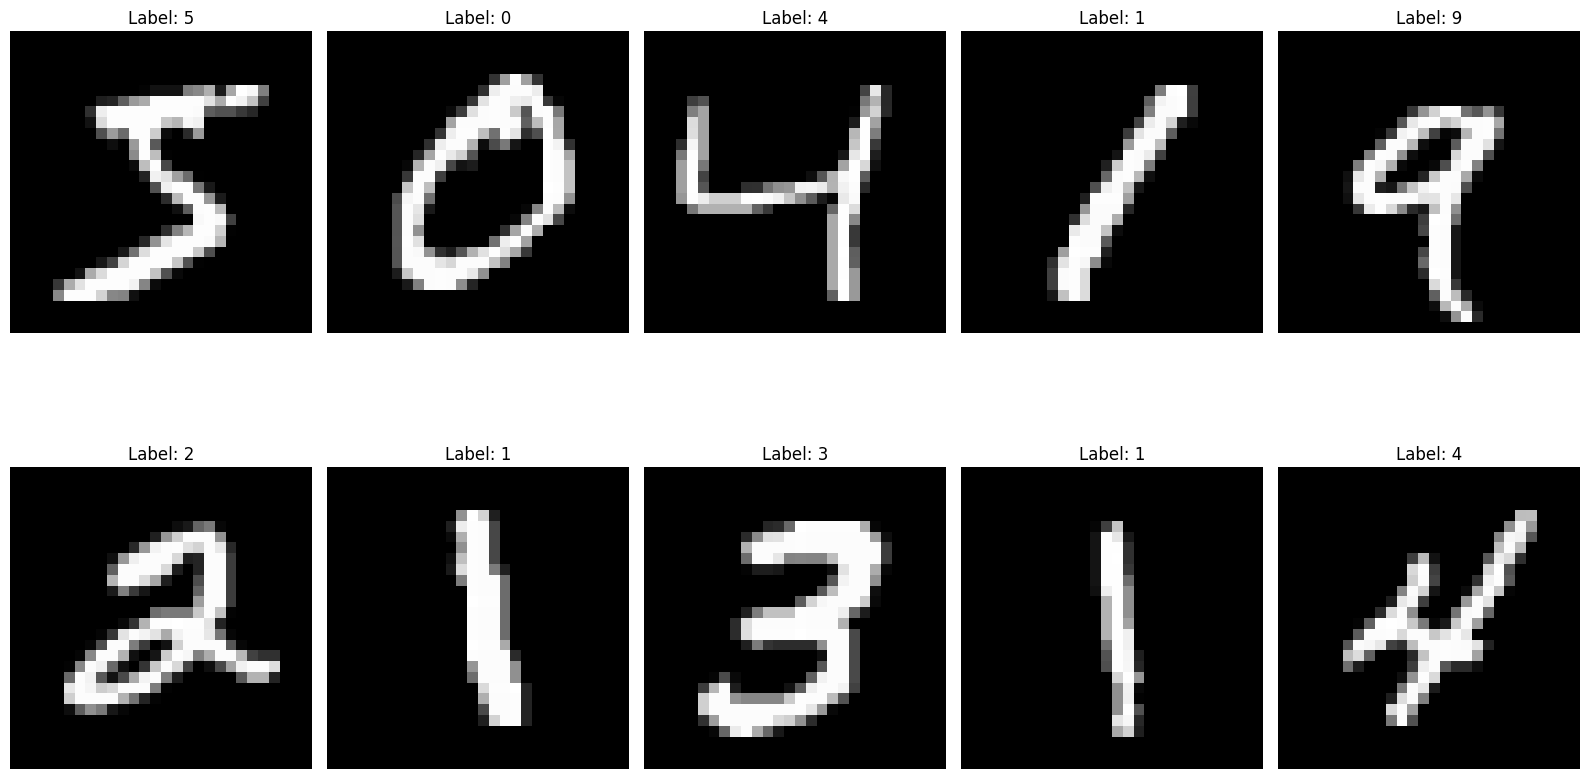

In [4]:
plt.figure(figsize=(16,10))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i],cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
print("Minimum Pixel Value:",X_train.min())
print("Maximum Pixel Value:",X_train.max())

Minimum Pixel Value: 0
Maximum Pixel Value: 255


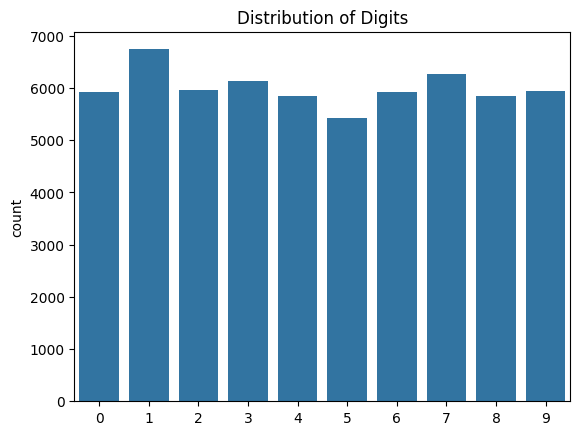

In [6]:
sns.countplot(x=y_train)
plt.title("Distribution of Digits")
plt.show()

In [7]:
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

In [8]:
X_train_flat = X_train.reshape((len(X_train),784))
X_test_flat = X_test.reshape((len(X_test),784))

In [9]:
X_train_flat = X_train.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)

print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


In [10]:
input_layer = Input(shape=(784,))

In [11]:
print(X_train_flat.shape)

(60000, 784)


In [12]:
input_dim = 784
input_layer = Input(shape=(input_dim,))

In [13]:
encoder = Dense(128,activation='relu')(input_layer)
encoder = Dense(64, activation='relu')(encoder)
latent_space = Dense(764, activation='sigmoid')(encoder)

In [14]:
decoder = Dense(64, activation='relu')(latent_space)
decoder = Dense(128, activation='relu')(decoder)
output_layer = Dense(784, activation='sigmoid')(decoder)

In [15]:
autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 764)            │        49,660 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        48,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,812 (1.21 MB)

 Trainable params: 316,812 (1.21 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
history = autoencoder.fit(
    X_train_flat,
    X_train_flat,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test_flat, X_test_flat)
)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 36ms/step - accuracy: 0.0081 - loss: 0.2538 - val_accuracy: 0.0069 - val_loss: 0.1815
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.0089 - loss: 0.1601 - val_accuracy: 0.0093 - val_loss: 0.1471
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.0096 - loss: 0.1401 - val_accuracy: 0.0113 - val_loss: 0.1315
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.0107 - loss: 0.1275 - val_accuracy: 0.0105 - val_loss: 0.1218
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.0122 - loss: 0.1204 - val_accuracy: 0.0125 - val_loss: 0.1162
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.0135 - loss: 0.1153 - val_accuracy: 0.0119 - val_loss: 0.1118
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.0136 - loss: 0.1108 - val_accuracy: 0.0116 - val_loss: 0.1076
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.0137 - loss: 0.1071 - val_acc

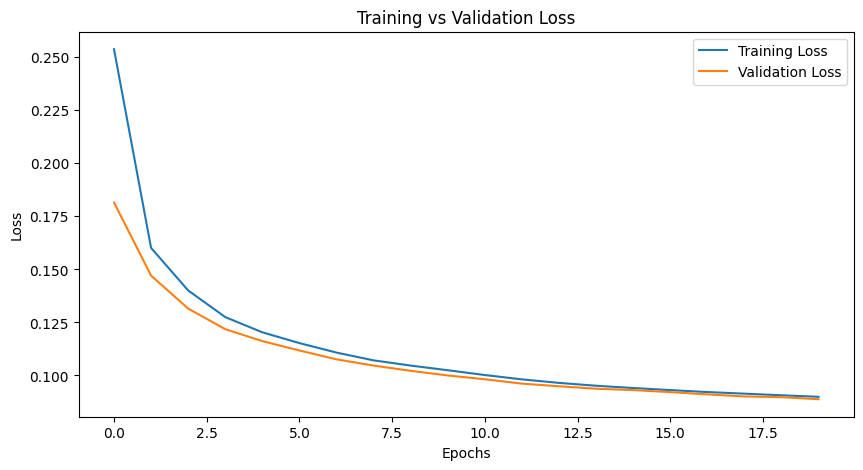

In [18]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

In [19]:
reconstructed_images = autoencoder.predict(X_test_flat)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [20]:
reconstructed_images = reconstructed_images.reshape(-1,28,28)

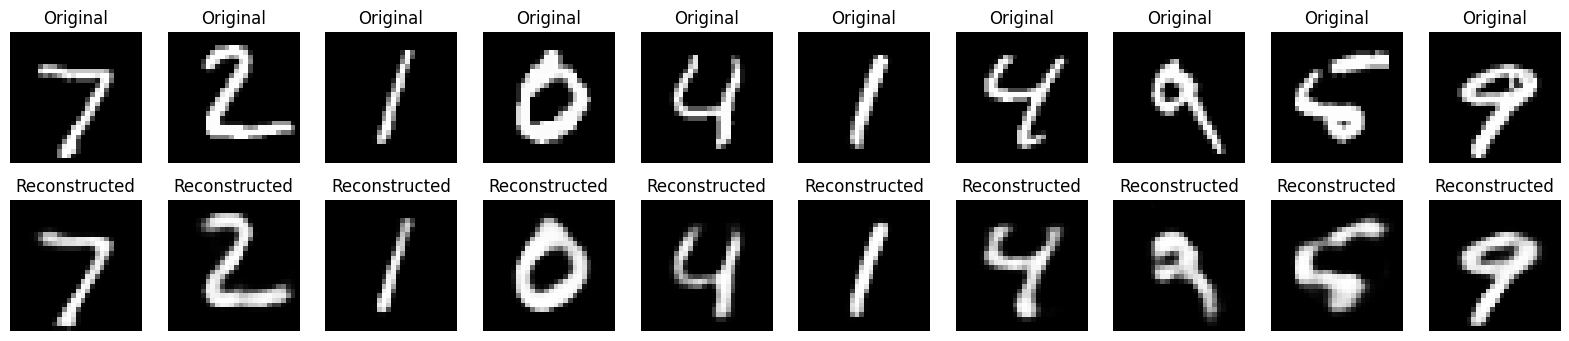

In [21]:
n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # Original
    ax = plt.subplot(2,n,i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2,n,i+n+1)
    plt.imshow(reconstructed_images[i], cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

In [22]:
encoder_model = Model(inputs=input_layer, outputs=latent_space)

In [23]:
latent_features = encoder_model.predict(X_test_flat)

print(latent_features.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 764)


In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

latent_2d = pca.fit_transform(latent_features)

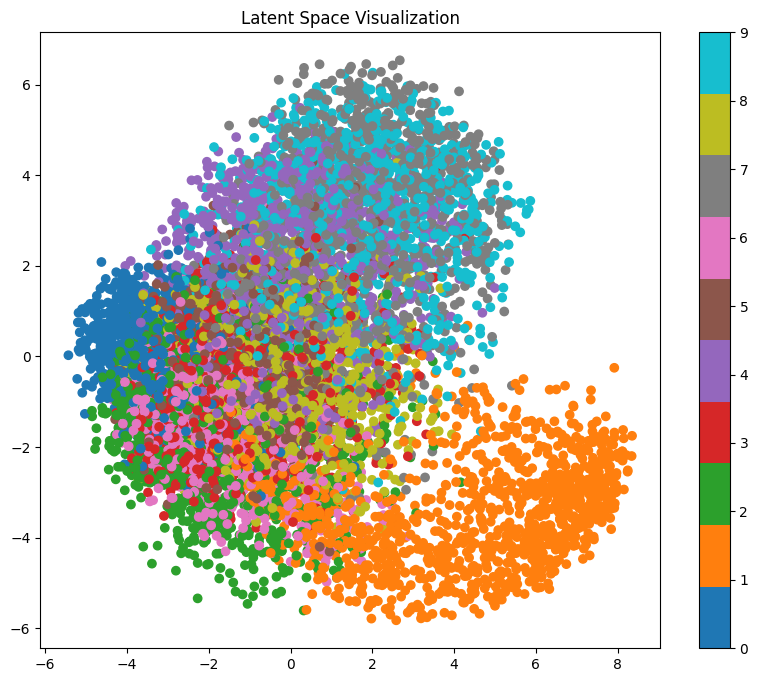

In [25]:
plt.figure(figsize=(10,8))

scatter = plt.scatter(
    latent_2d[:,0],
    latent_2d[:,1],
    c=y_test,
    cmap='tab10'
)

plt.colorbar(scatter)
plt.title("Latent Space Visualization")
plt.show()

In [26]:
mse = np.mean(np.square(X_test - reconstructed_images), axis=(1,2))

print(mse[:10])

[0.00373462 0.01583652 0.00136654 0.0070176  0.00707356 0.0008976
 0.01129564 0.0163743  0.01838608 0.00676257]


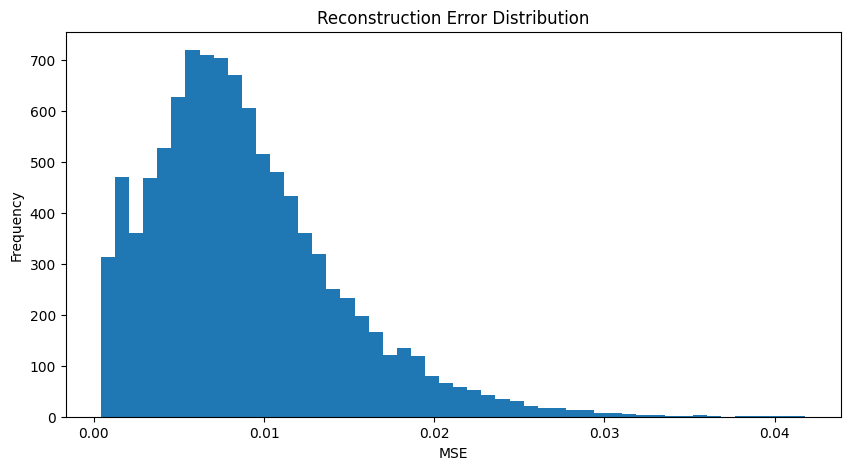

In [27]:
plt.figure(figsize=(10,5))

plt.hist(mse, bins=50)
plt.title("Reconstruction Error Distribution")
plt.xlabel("MSE")
plt.ylabel("Frequency")

plt.show()

In [28]:
noise_factor = 0.5

X_train_noisy = X_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_train.shape
)

X_test_noisy = X_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=X_test.shape
)

X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

In [29]:
X_train_noisy_flat = X_train_noisy.reshape(-1,784)
X_test_noisy_flat = X_test_noisy.reshape(-1,784)

In [30]:
history_noise = autoencoder.fit(
    X_train_noisy_flat,
    X_train_flat,
    epochs=10,
    batch_size=256,
    validation_data=(X_test_noisy_flat, X_test_flat)
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.0122 - loss: 0.1433 - val_accuracy: 0.0110 - val_loss: 0.1245
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.0123 - loss: 0.1233 - val_accuracy: 0.0114 - val_loss: 0.1211
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.0126 - loss: 0.1203 - val_accuracy: 0.0114 - val_loss: 0.1195
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.0132 - loss: 0.1188 - val_accuracy: 0.0134 - val_loss: 0.1187
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.0132 - loss: 0.1176 - val_accuracy: 0.0119 - val_loss: 0.1180
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.0134 - loss: 0.1167 - val_accuracy: 0.0134 - val_loss: 0.1163
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.0128 - loss: 0.1159 - val_accuracy: 0.0145 - val_loss: 0.1158
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - accuracy: 0.0133 - loss: 0.1152 - val_ac

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


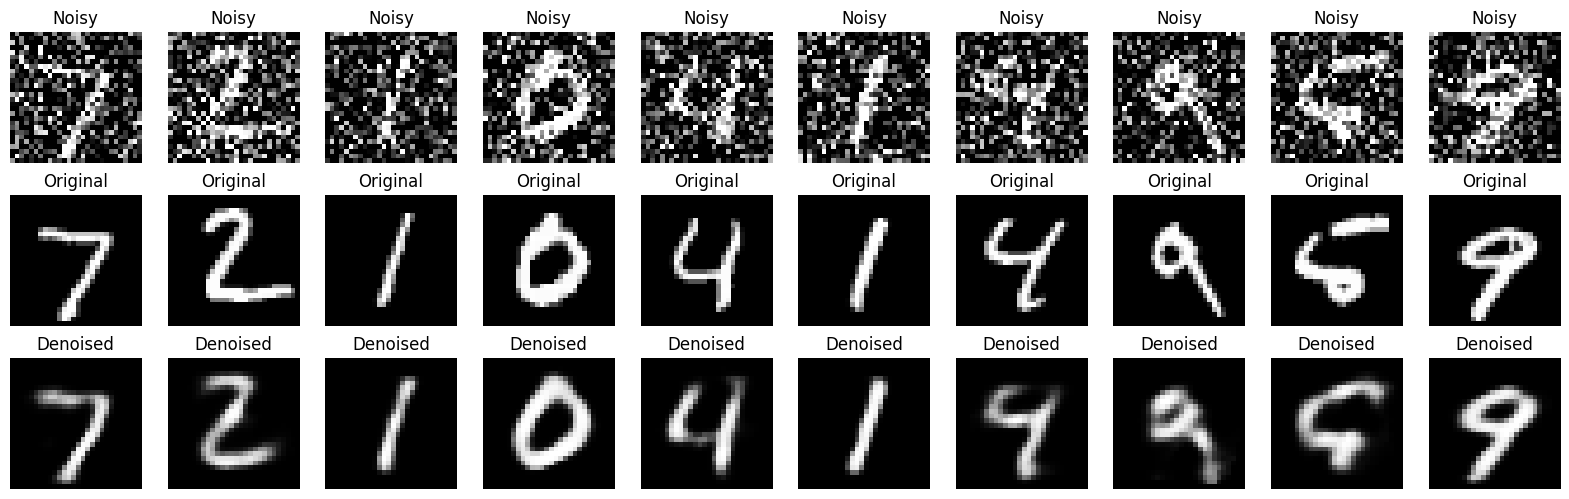

In [31]:
denoised_images = autoencoder.predict(X_test_noisy_flat)
denoised_images = denoised_images.reshape(-1,28,28)

plt.figure(figsize=(20,6))

for i in range(10):

    # Noisy
    ax = plt.subplot(3,10,i+1)
    plt.imshow(X_test_noisy[i], cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Original
    ax = plt.subplot(3,10,i+11)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Denoised
    ax = plt.subplot(3,10,i+21)
    plt.imshow(denoised_images[i], cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.show()

In [32]:
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [33]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D

input_img = Input(shape=(28,28,1))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

cnn_autoencoder = Model(input_img, decoded)

cnn_autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
cnn_autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [35]:
cnn_autoencoder.fit(
    X_train_cnn,
    X_train_cnn,
    epochs=10,
    batch_size=128,
    validation_data=(X_test_cnn, X_test_cnn)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 126s 264ms/step - loss: 0.1193 - val_loss: 0.0789
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 122s 261ms/step - loss: 0.0771 - val_loss: 0.0744
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 125s 267ms/step - loss: 0.0741 - val_loss: 0.0724
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 135s 251ms/step - loss: 0.0725 - val_loss: 0.0713
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 246ms/step - loss: 0.0714 - val_loss: 0.0704
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 105s 225ms/step - loss: 0.0707 - val_loss: 0.0697
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 105s 225ms/step - loss: 0.0701 - val_loss: 0.0693
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 224ms/step - loss: 0.0696 - val_loss: 0.0688
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 147s 234ms/step - loss: 0.0692 - val_loss: 0.0685
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 152s 256ms/step - loss: 0.0688 - val_loss: 0.0681


In [36]:
decoded_imgs = cnn_autoencoder.predict(X_test_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step


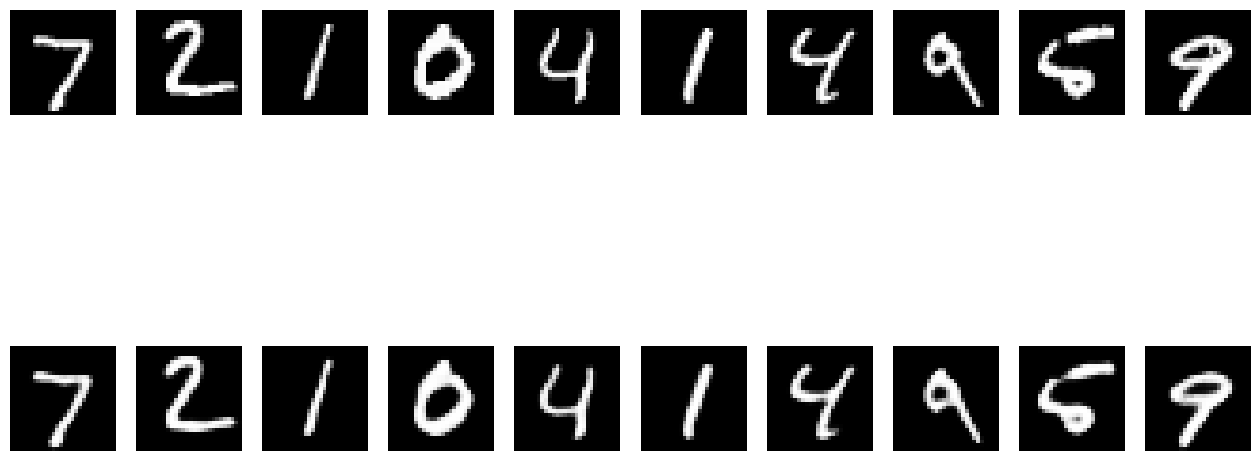

In [37]:
plt.figure(figsize=(16,8))

for i in range(10):
  ax = plt.subplot(2,10,i+1)
  plt.imshow(X_test_cnn[i].reshape(28,28),cmap='gray')
  plt.axis('off')

  ax = plt.subplot(2,10,i+11)
  plt.imshow(decoded_imgs[i].reshape(28,28),cmap='gray')
  plt.axis('off')

plt.show()

In [40]:
autoencoder.save("mnist_autoencoder.h5")

In [41]:
from tensorflow.keras.models import load_model

model = load_model("mnist_autoencoder.h5")